# Intro

In [1]:
import pandas as pd
df = pd.read_csv("glovo_ops_data_final.csv")
df.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734.0,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,5.0,NaN,48.861046,2.275441,48.855068,2.283378,66.0
1,29.0,1648235.0,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN,NaN,48.871578,2.304495,48.867017,2.292787,40.0
2,292.0,13527080.0,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,5.0,NaN,48.855461,2.360776,48.866713,2.364773,29.0
3,743.0,275173.0,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,NaN,NaN,48.859665,2.285694,48.884335,2.259989,54.0
4,838.0,1105241.0,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,5.0,NaN,48.863417,2.361240,48.868087,2.371050,77.0




**ESTIMATED TIME OF ARRIVAL**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19914 entries, 0 to 19913
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     19914 non-null  float64
 1   customer_id                  19913 non-null  float64
 2   courier_id                   19913 non-null  float64
 3   store_address_id             16273 non-null  float64
 4   store_name                   16273 non-null  object 
 5   vertical                     19913 non-null  object 
 6   gtv                          19913 non-null  float64
 7   delivery_fee                 19913 non-null  float64
 8   description                  19905 non-null  object 
 9   activation_time_local        19913 non-null  object 
 10  courier_started_order_local  19912 non-null  object 
 11  pickup_time_local            19913 non-null  object 
 12  delivery_time_local          19913 non-null  object 
 13  tranport_type   

# EDA

## Variables tipo Object

Hemos decidido eliminar:
* **Store Name**_ Variable de poca calidad, faltan muchos valores. La eliminamos.
* **Description** Variable que no podemos usar efectivamente, la eliminamos (recordar para el apartado final)
* **Bad rating reason**: Variable que no podemos usar efectivamente, la eliminamos (recordar para el apartado final)

In [4]:
df.select_dtypes(include="object").head(3)

,store_name,vertical,description,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,bad_rating_reason
0,Pharmacie,WALL - Partner,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,NaN
1,Starbucks,WALL - NonPartner,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN
2,Starbucks,WALL - NonPartner,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,NaN


In [5]:
object_var = ["tranport_type","vertical"]

for i in object_var:
  print(df[i].unique())

['MOTORBIKE' 'BICYCLE' 'CAR' 'WALKER' nan]
['WALL - Partner' 'WALL - NonPartner' 'COURIER' nan]


/tmp/ipykernel_7449/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7449/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7449/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7449/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

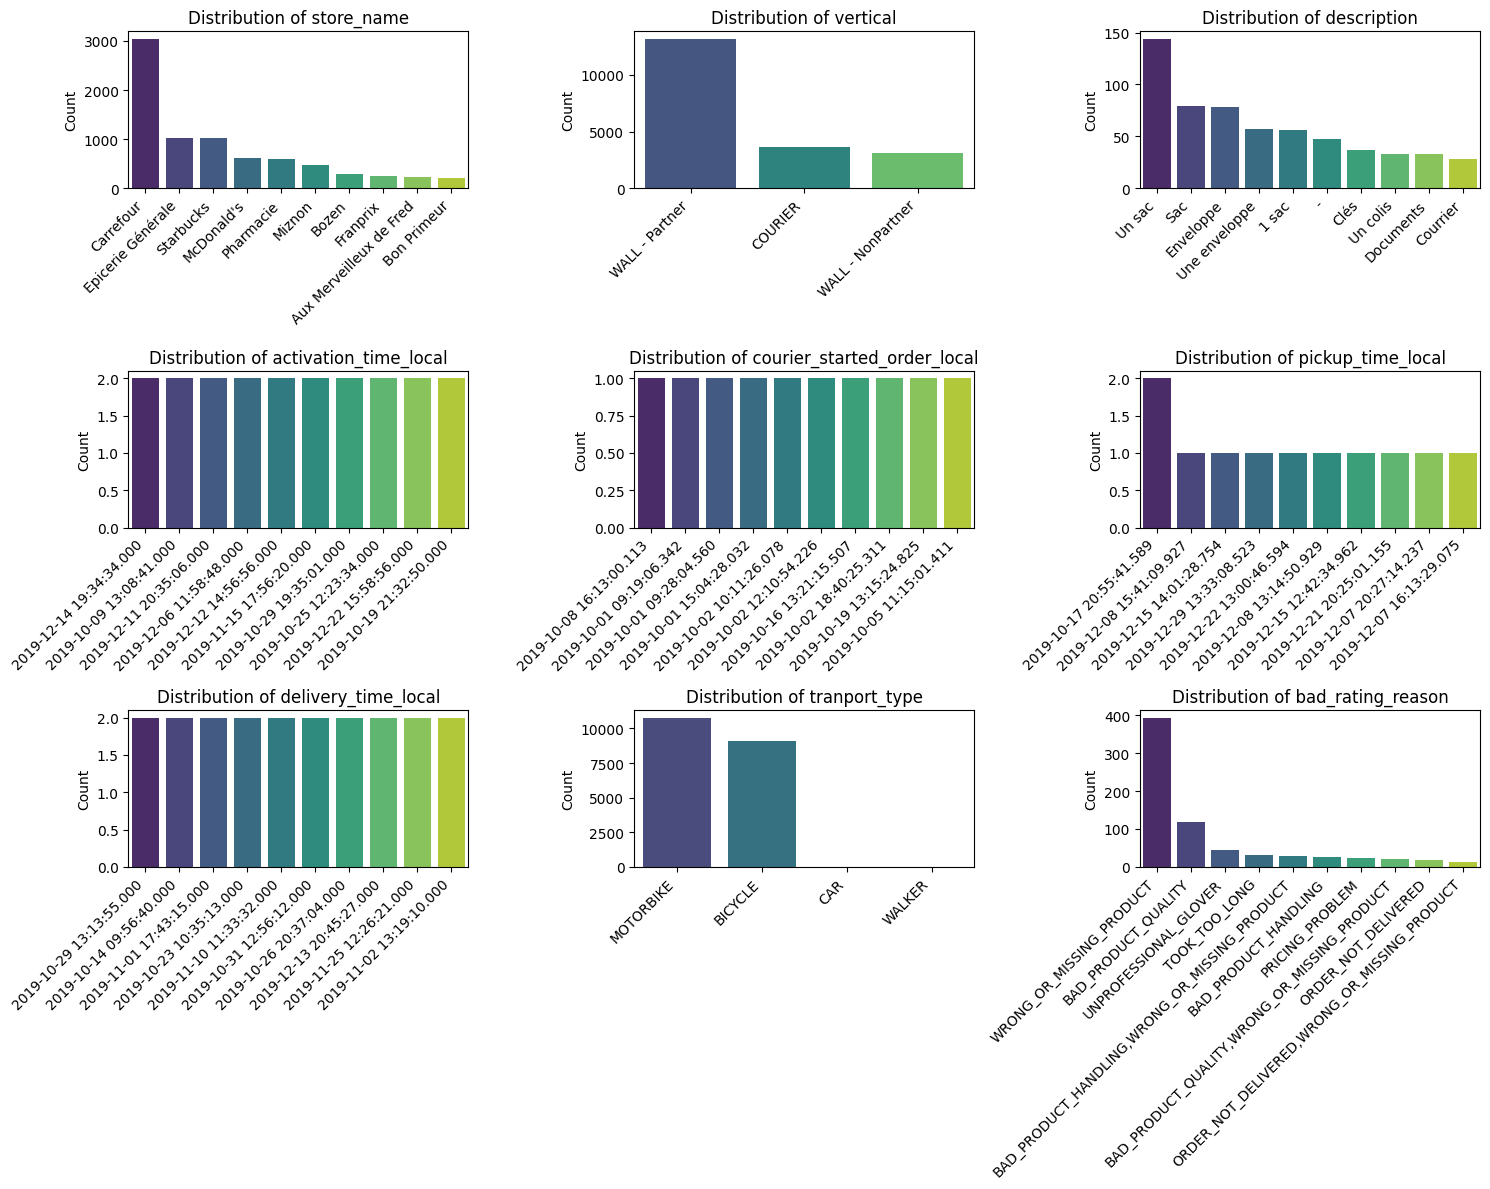

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


# Get object type columns. This was previously identified.
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Determine the number of subplots and grid layout
n_cols = 3 # Number of columns for the subplot grid
n_rows = (len(object_columns) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(object_columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Count value frequencies and take top N values (e.g., top 10)
    # This prevents overcrowded plots for columns with many unique values
    top_values = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')

    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('') # Remove x-label as title is descriptive
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

Variables Object:
Cuatro de tipo object son en realidad datetimes.
* Cuatro variables de tiempo:
  * **activation_time_local**
  * **courier_started_order_local**
  * **pickup_time_local**
  * **delivery_time_local**


A efectos del trabajo, únicamente neceistamos el tiempo desde el inicio hasta el final. Así pues, calcularemos la variable target como resultado de delivery_time_local - activation_time_local y eliminaremos los cuatro timestamps para que no pasen a la fase del modelo

### Fechas

ESTIMATED TIME OF ARRIVAL

Definición de la Variable Objetivo: Se crea delivery_time_minutes, que representa el tiempo total de ciclo del pedido. Al ser la variable que el modelo intentará predecir, se establece como el eje central del estudio.

In [7]:
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'], errors='coerce')
df['courier_started_order_local'] = pd.to_datetime(df['courier_started_order_local'], errors='coerce')
df['pickup_time_local'] = pd.to_datetime(df['pickup_time_local'], errors='coerce')
df['delivery_time_local'] = pd.to_datetime(df['delivery_time_local'], errors='coerce')

# Drop rows where any of the datetime columns converted to NaT
datetime_cols = ['activation_time_local', 'courier_started_order_local', 'pickup_time_local', 'delivery_time_local']
df.dropna(subset=datetime_cols, inplace=True)

# Crear variables para poder explorar en el EDA
df['delivery_time_minutes'] = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60
df['hour_of_day'] = df['activation_time_local'].dt.hour
df['day_of_week'] = df['activation_time_local'].dt.dayofweek

In [8]:
print('Years in the dataset:', df['activation_time_local'].dt.year.unique())
print('Months in the dataset:', df['activation_time_local'].dt.month.unique())

Years in the dataset: [2019]
Months in the dataset: [10 11 12]


¿Qué es el ETA y por qué es crítico?
El ETA (Estimated Time of Arrival) es el tiempo estimado de llegada. En el contexto de una plataforma como Glovo, representa la promesa de entrega que se le hace al usuario final.

Técnicamente, el ETA es el resultado de la suma de varios micro-tiempos:

Tiempo de Reacción: Desde la activación hasta que un repartidor acepta.

Tiempo de Preparación: Lo que tarda el establecimiento en tener el pedido listo.

Tiempo de Tránsito: El desplazamiento físico desde el punto A (tienda) al punto B (cliente).

In [9]:
df['delivery_time_minutes'].describe()

,delivery_time_minutes
count,19912.000000
mean,38.194833
std,15.686323
min,3.633333
25%,27.366667
50%,35.183333
75%,45.433333
max,136.600000


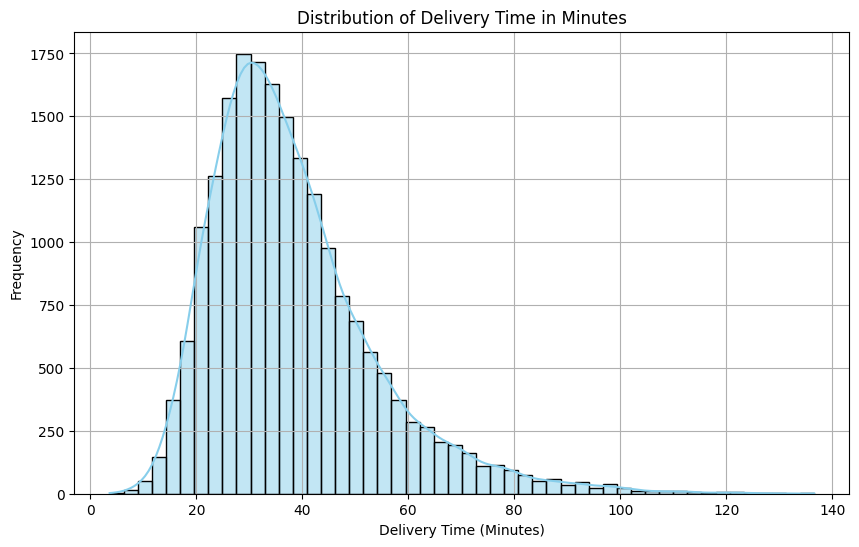

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time_minutes'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Delivery Time in Minutes')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

/tmp/ipykernel_7449/4043450601.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,


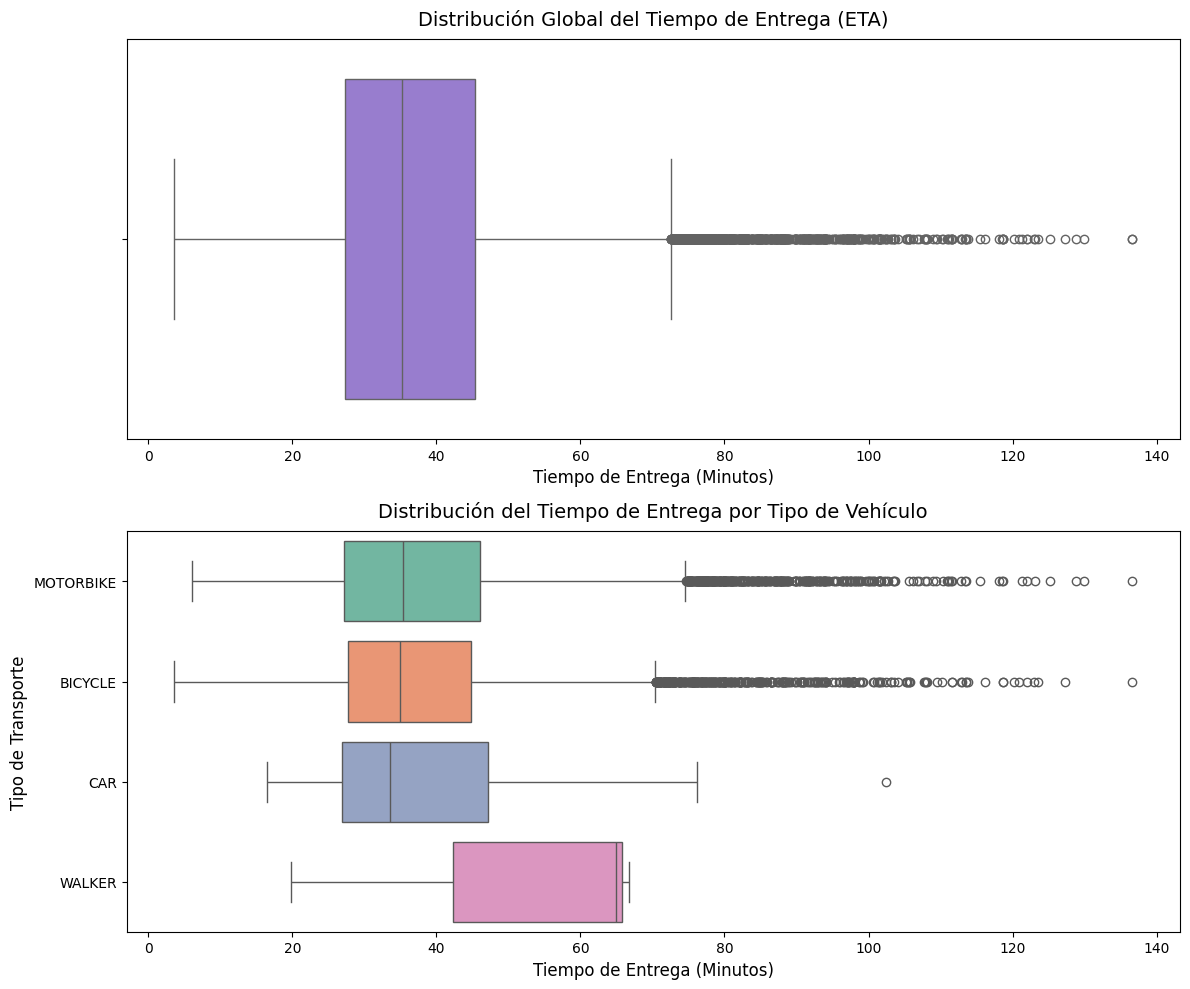

In [11]:
 #Crear una figura con dos subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Gráfico de Caja Global
sns.boxplot(data=df, x='delivery_time_minutes', color='mediumpurple', ax=axes[0])
axes[0].set_title('Distribución Global del Tiempo de Entrega (ETA)', fontsize=14, pad=10)
axes[0].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)


# 2. Gráfico de Caja segmentado por Tipo de Transporte (si tienes la columna)
# Nota: Asegúrate de que la columna se llame 'transport_type' o 'tranport_type' según tu dataset
nombre_columna_transporte = 'tranport_type' # Ajusta esto si tu columna tiene otro nombre

if nombre_columna_transporte in df.columns:
    sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,
                palette='Set2', ax=axes[1])
    axes[1].set_title('Distribución del Tiempo de Entrega por Tipo de Vehículo', fontsize=14, pad=10)
    axes[1].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)
    axes[1].set_ylabel('Tipo de Transporte', fontsize=12)
else:
    axes[1].set_visible(False) # Oculta el segundo gráfico si no existe la columna

plt.tight_layout()
plt.show()


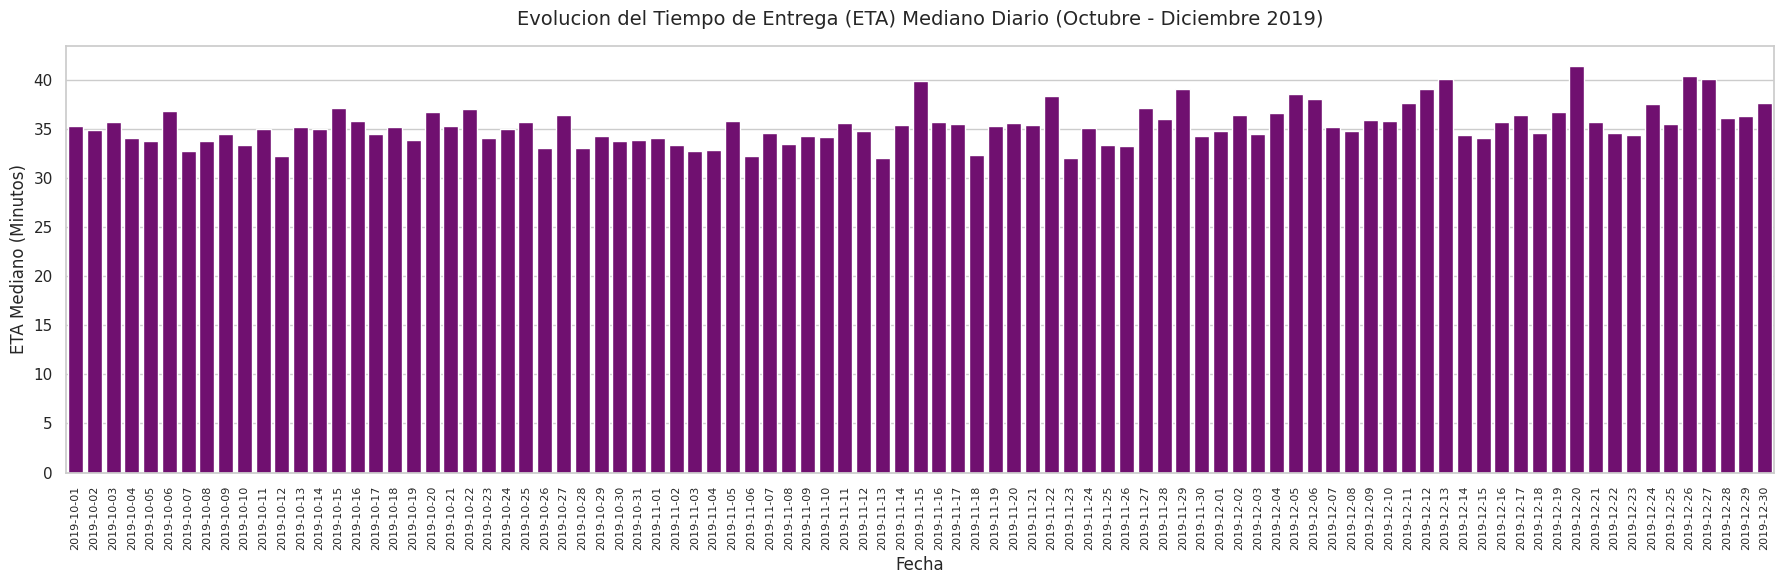

In [12]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Asegurarnos de tener la columna 'date'
df['date'] = df['activation_time_local'].dt.date

# 2. Asegurarnos de tener el tiempo de entrega en minutos
# Si utilizaste 'ETA_seconds' en el paso anterior, lo dividimos por 60.
if 'delivery_time_minutes' not in df.columns:
    df['delivery_time_minutes'] = df['ETA_seconds'] / 60

# 3. Agrupar y calcular el ETA (tiempo de entrega) MEDIANO por cada día
eta_por_dia = df.groupby('date')['delivery_time_minutes'].median().reset_index()

# 4. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6))

# Utilizamos color morado para contrastar con los anteriores
sns.barplot(data=eta_por_dia, x='date', y='delivery_time_minutes', color='purple')

plt.title('Evolucion del Tiempo de Entrega (ETA) Mediano Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('ETA Mediano (Minutos)', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

Se observa una tendencia clara de crecimiento conforme avanza la semana. Mientras que el lunes y martes presentan los tiempos más ágiles, el viernes, sábado y domingo muestran los mayores tiempos de espera medianos.

## Variables tipo numerical

Hemos decidido eliminar:
* **Order_id** El código de identificación de la orden no aporta ninguna información estadística, la eliminamos
* **Customer_id** El código de identificación del cliente tampoco aporta ninguna información relevante para la predicción del ETA. la eliminamos
* **Rating** Faltan muhcas observaciones y es de poca calidad


In [13]:
df.select_dtypes(include=["float","int"]).head(3)

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,delivery_time_minutes,hour_of_day,day_of_week
0,32.0,700734.0,441.0,10887.0,19.97,4.9,5.0,48.861046,2.275441,48.855068,2.283378,66.0,28.466667,9,1
1,29.0,1648235.0,239.0,3705.0,10.50,4.9,NaN,48.871578,2.304495,48.867017,2.292787,40.0,29.150000,9,1
2,292.0,13527080.0,351.0,1035.0,10.35,4.9,5.0,48.855461,2.360776,48.866713,2.364773,29.0,30.033333,15,1


In [14]:
df.select_dtypes(include=["float","int"]).describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,delivery_time_minutes,hour_of_day,day_of_week
count,19912.000000,1.991200e+04,19912.000000,16272.000000,19912.000000,19912.000000,8366.000000,19912.000000,19912.000000,19912.000000,19912.000000,19912.000000,19912.000000,19912.000000,19912.000000
mean,41622.207362,7.385929e+06,280.143080,42910.544678,23.698964,5.555782,4.827158,48.864076,2.322018,48.864168,2.318437,78.018682,38.194833,15.662967,3.079902
std,24863.903677,8.224393e+06,139.150445,41444.247790,17.952226,3.632358,0.812048,0.017257,0.037378,0.020106,0.040753,36.151716,15.686323,3.918454,1.990509
min,1.000000,3.142000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.225742,48.796142,2.211807,20.000000,3.633333,8.000000,0.000000
25%,19956.750000,1.091623e+06,167.000000,7139.000000,12.900000,3.900000,5.000000,48.852499,2.290031,48.850424,2.287326,51.000000,27.366667,12.000000,1.000000
50%,40909.500000,3.270408e+06,303.000000,23886.000000,18.500000,3.900000,5.000000,48.866397,2.322111,48.865371,2.314676,74.000000,35.183333,16.000000,3.000000
75%,63343.000000,1.173551e+07,402.000000,78604.000000,28.692500,6.900000,5.000000,48.876436,2.350029,48.878877,2.348344,98.000000,45.433333,19.000000,5.000000
max,85120.000000,2.986686e+07,534.000000,136345.000000,346.620000,21.500000,5.000000,48.915573,2.437825,48.924132,2.443143,239.000000,136.600000,23.000000,6.000000


In [15]:
df.select_dtypes(include=['object']).columns

Index(['store_name', 'vertical', 'description', 'tranport_type',
       'bad_rating_reason', 'date'],
      dtype='object')

### Análisis de la Saturación de Flota
En esta sección del EDA, analizamos la variable Saturación, que mide la relación entre la demanda de pedidos y la disponibilidad de repartidores en tiempo real. Entender este comportamiento es vital, ya que la saturación suele ser el principal cuello de botella que degrada la precisión del ETA.

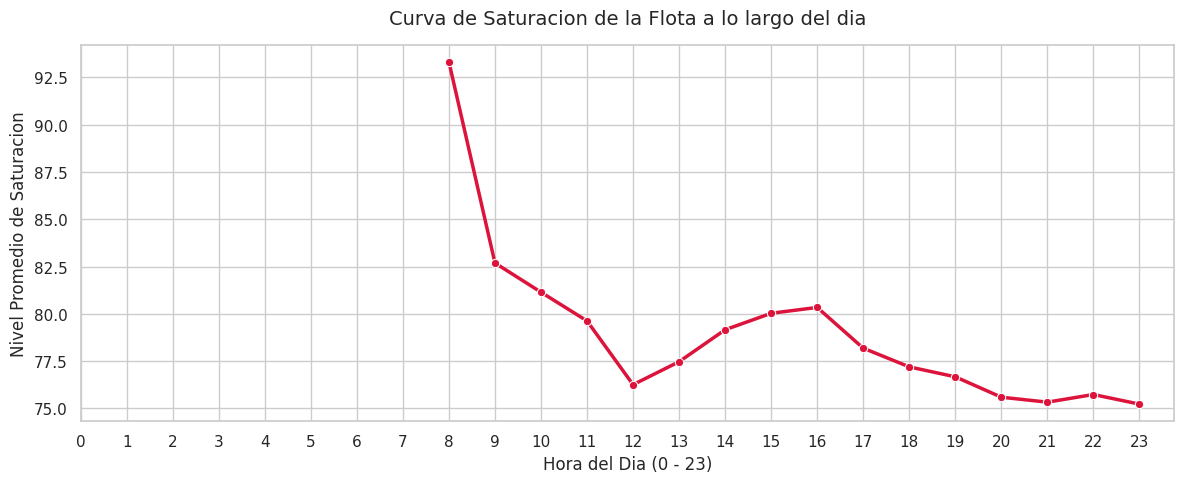

/tmp/ipykernel_7449/3714337590.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.mean, errorbar=None)


<Figure size 1000x500 with 0 Axes>

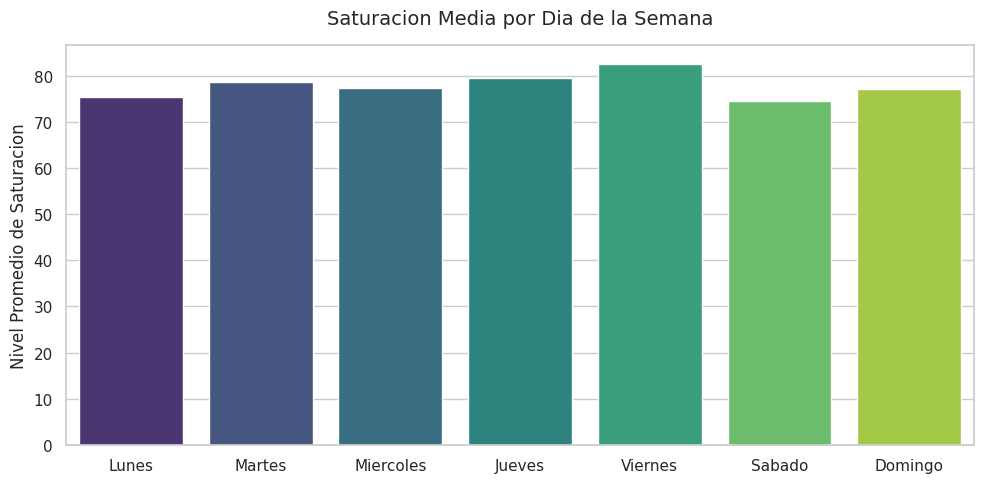

In [16]:
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico 1: Saturación promedio a lo largo de las 24 horas del día
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour_of_day', y='saturation', estimator='mean',
             errorbar=None, marker='o', linewidth=2.5, color='crimson')
plt.title('Curva de Saturacion de la Flota a lo largo del dia', fontsize=14, pad=15)
plt.xlabel('Hora del Dia (0 - 23)', fontsize=12)
plt.ylabel('Nivel Promedio de Saturacion', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# Configuración visual
plt.figure(figsize=(10, 5))
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# Cambiamos np.median por np.mean para obtener el promedio
sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.mean, errorbar=None)

plt.title('Saturacion Media por Dia de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Nivel Promedio de Saturacion', fontsize=12)
plt.tight_layout()
plt.show()

Al comparar la curva de saturación con el volumen de pedidos, se observa un fenómeno contraelectivo: aunque el volumen total de pedidos suele ser alto durante la cena, la saturación relativa tiende a ser menor o más estable que en el almuerzo

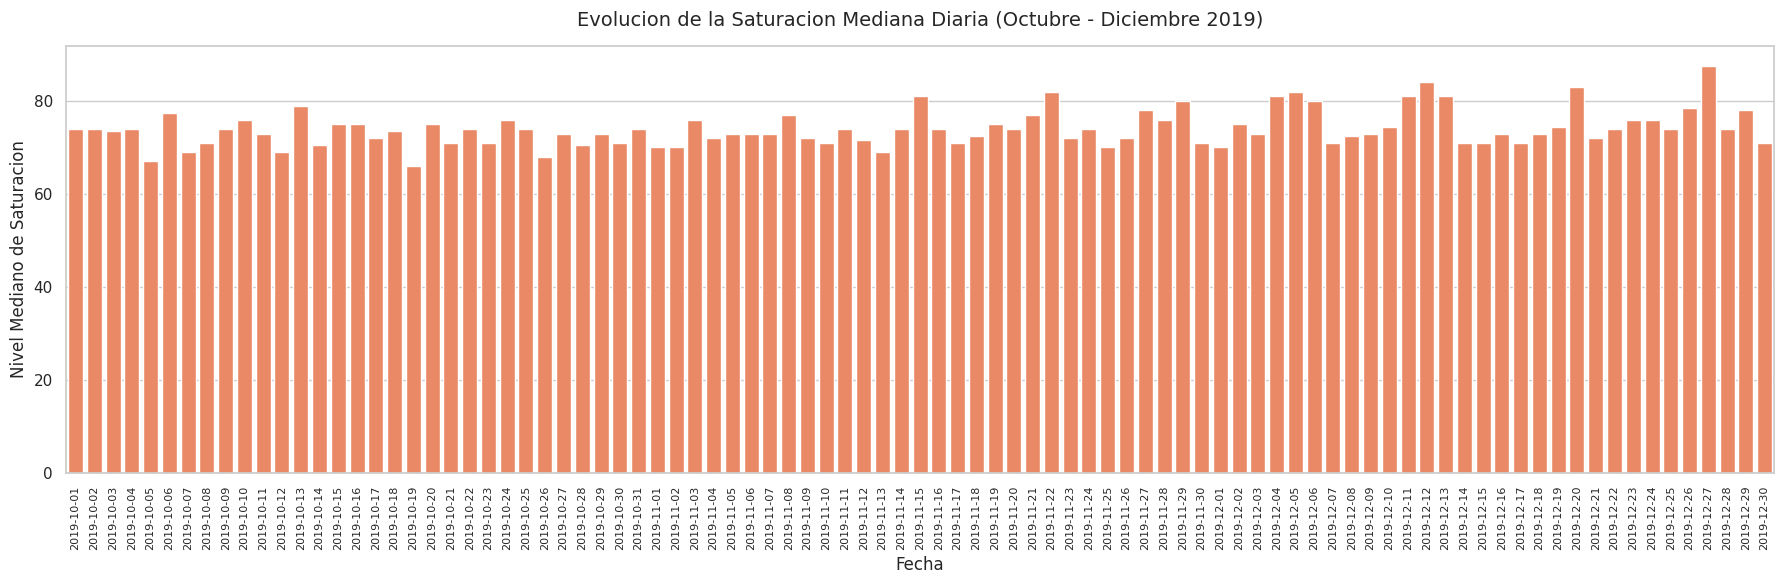

In [17]:
# 2. Agrupar y calcular la saturación MEDIANA por cada día exacto
saturacion_por_dia = df.groupby('date')['saturation'].median().reset_index()

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Ampliamos el ancho para acomodar bien todos los días

# Usamos barplot manteniendo el color coral para diferenciarlo de los pedidos
sns.barplot(data=saturacion_por_dia, x='date', y='saturation', color='coral')

plt.title('Evolucion de la Saturacion Mediana Diaria (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Mediano de Saturacion', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

### Volumen de pedidos

/tmp/ipykernel_7449/3357885963.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')


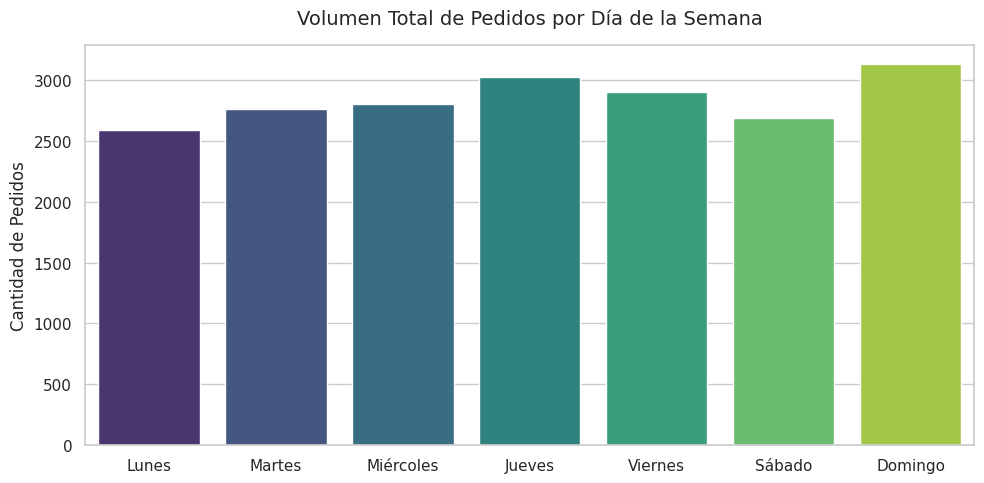

In [18]:
# GRÁFICO 1: Volumen de pedidos por Día de la Semana
# ==============================================================================
plt.figure(figsize=(10, 5))

# countplot para contar pedidos por día
ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')

# Etiquetas profesionales en lugar de números (0=Lunes, 6=Domingo)
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
plt.title('Volumen Total de Pedidos por Día de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Cantidad de Pedidos', fontsize=12)

plt.tight_layout()
plt.show()

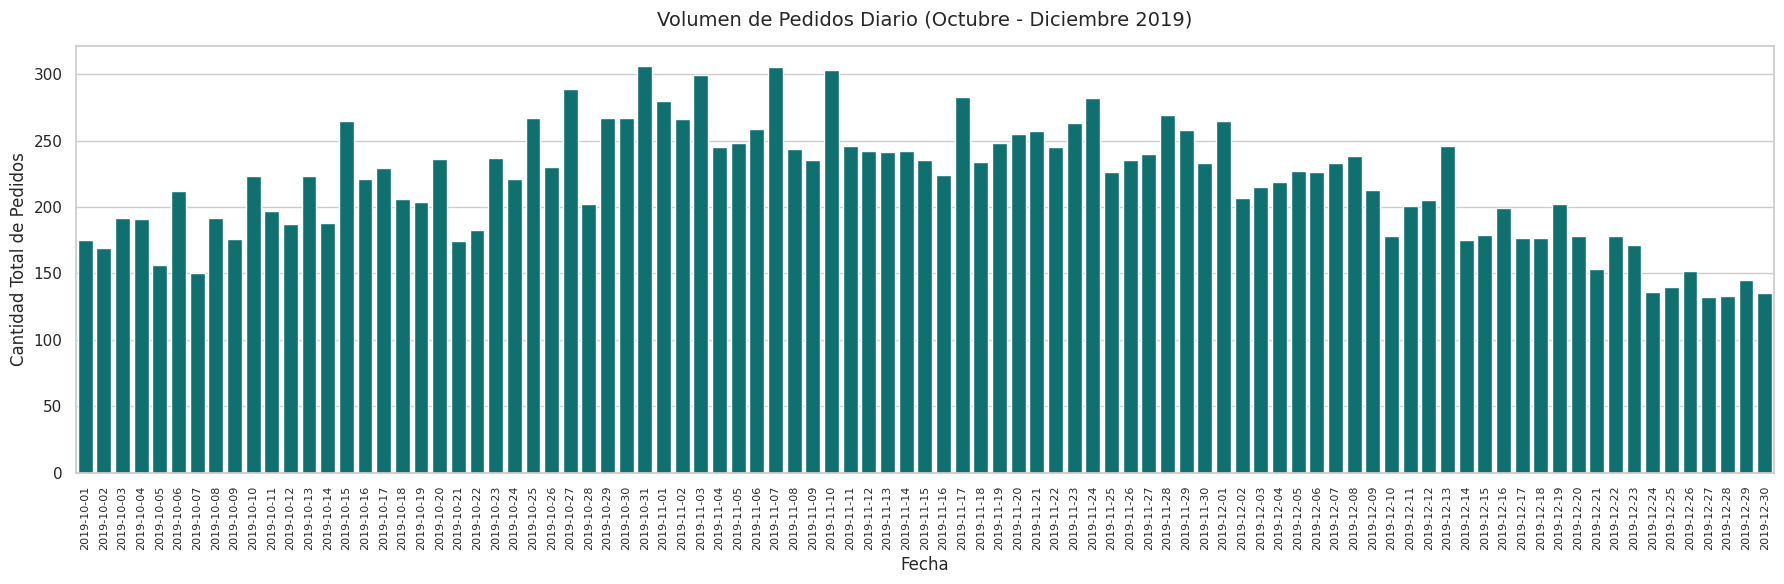

In [19]:
# 1. Extraer solo la fecha (año-mes-día) descartando la hora
df['date'] = df['activation_time_local'].dt.date

# 2. Agrupar y contar la cantidad de pedidos por cada día exacto
pedidos_por_dia = df.groupby('date').size().reset_index(name='cantidad_pedidos')

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Hacemos la figura un poco más ancha para acomodar los 90 días

# Utilizamos color='teal' para mantener tu paleta, o puedes usar palette='viridis' si prefieres gradiente
sns.barplot(data=pedidos_por_dia, x='date', y='cantidad_pedidos', color='teal')

plt.title('Volumen de Pedidos Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad Total de Pedidos', fontsize=12)

# Rotar las fechas del eje X a 90 grados y reducir un poco la fuente para que quepan bien
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7449/1818695749.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour_of_day', palette='Blues_r')


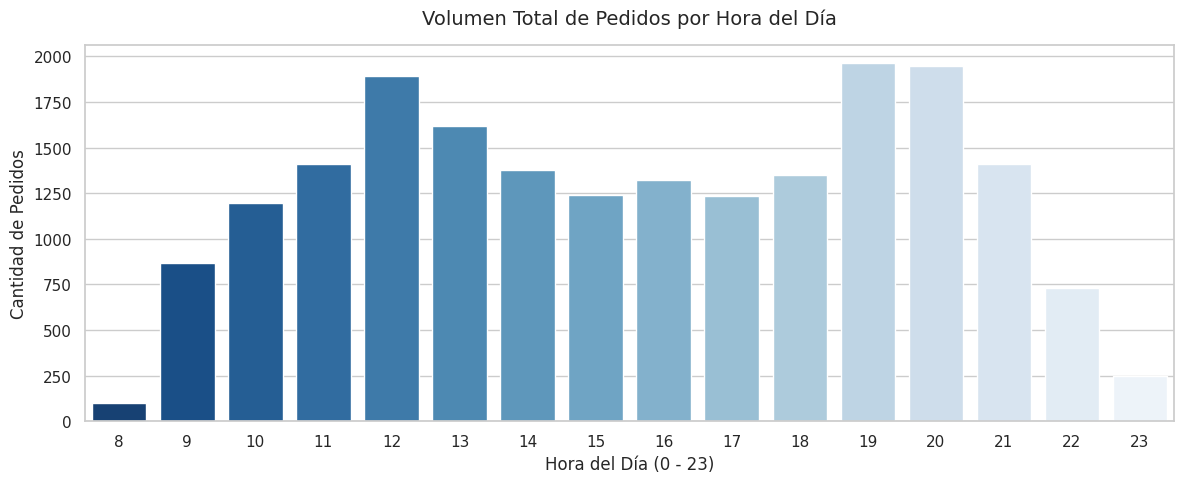

In [20]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico: Cantidad total de pedidos por hora del día
plt.figure(figsize=(12, 5))

# countplot cuenta automáticamente cuántas veces aparece cada hora en el dataset
sns.countplot(data=df, x='hour_of_day', palette='Blues_r')

plt.title('Volumen Total de Pedidos por Hora del Día', fontsize=14, pad=15)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)

# Aseguramos que se muestren todas las horas en el eje X
# Nota: Si en tus datos no hay pedidos de madrugada (ej. 3 AM o 4 AM),
# Seaborn solo mostrará las horas con datos.
plt.tight_layout()
plt.show()

Con justa razon los horarios que hay mas volumen de pedidos son en los horarios de almuerzo y cena

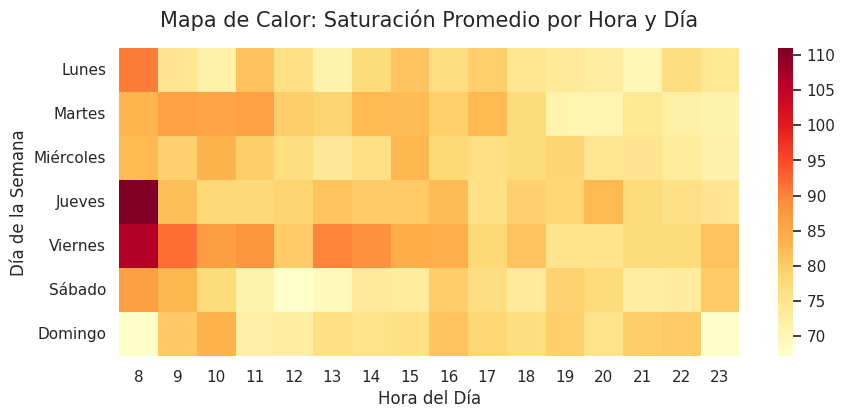

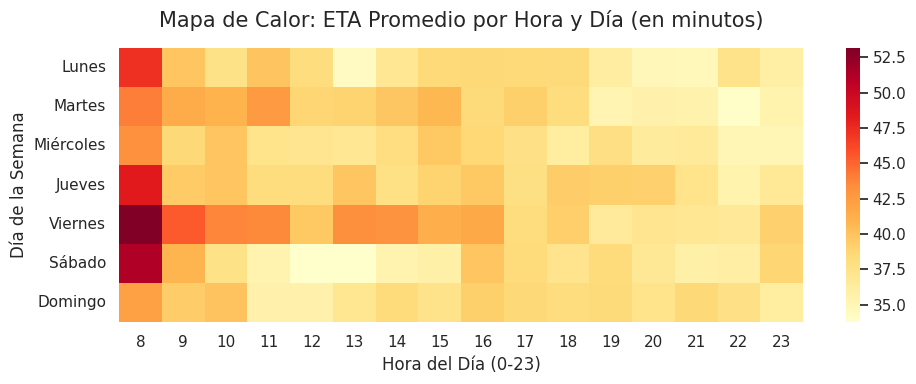

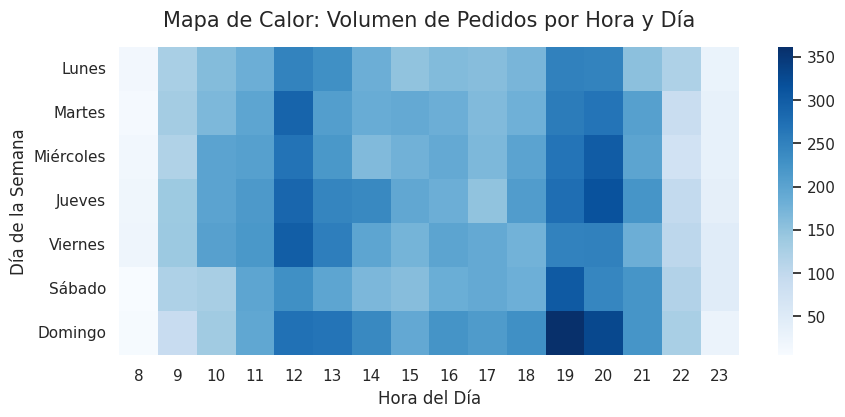

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar los datos (Asegúrate de tener hour_of_day y day_of_week)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Crear tabla pivote para Saturación (Promedio)
pivot_saturacion = df.pivot_table(index='day_of_week', columns='hour_of_day', values='saturation', aggfunc='mean')

# Crear tabla pivote para Volumen (Conteo de pedidos)
pivot_volumen = df.pivot_table(index='day_of_week', columns='hour_of_day', values='order_id', aggfunc='count')

# --- GRÁFICO 1: MAPA DE CALOR DE SATURACIÓN ---
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_saturacion, cmap='YlOrRd', annot=False, yticklabels=dias)
plt.title('Mapa de Calor: Saturación Promedio por Hora y Día', fontsize=15, pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()

# 1. Crear la tabla pivote para el ETA Promedio
pivot_eta = df.pivot_table(index='day_of_week',
                           columns='hour_of_day',
                           values='delivery_time_minutes',
                           aggfunc='mean')

# 2. Configuración del gráfico
plt.figure(figsize=(10, 4))
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

sns.heatmap(pivot_eta, cmap='YlOrRd', annot=False, yticklabels=dias)

plt.title('Mapa de Calor: ETA Promedio por Hora y Día (en minutos)', fontsize=15, pad=15)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: MAPA DE CALOR DE VOLUMEN DE PEDIDOS ---
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_volumen, cmap='Blues', annot=False, yticklabels=dias)
plt.title('Mapa de Calor: Volumen de Pedidos por Hora y Día', fontsize=15, pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()


## Saturación, Volumen y ETA

Al cruzar los tres mapas de calor, identificamos una jerarquía de impacto que es fundamental para el diseño del modelo predictivo:
1. La Correlación Crítica: Saturación $\rightarrow$ ETALa inspección visual confirma que el mapa de Saturación y el de ETA Medio son casi "espejos".


      *   Interpretación: La saturación es el predictor más fiable del tiempo de entrega. Cuando el ratio de pedidos por repartidor disponible se desequilibra, el sistema pierde capacidad de reacción y el ETA se dispara inmediatamente, independientemente de si el volumen total de pedidos es alto o bajo.

2. La Paradoja del Volumen: las horas de mayor volumen (picos azules oscuros) no siempre se traducen en un ETA más alto.

      *   ¿Por qué ocurre esto?: Durante las horas punta previstas (como la cena), Glovo despliega su máxima capacidad de flota. Si hay 1.000 pedidos pero tienes 1.100 repartidores en calle, el sistema fluye.

      *   El Peligro de la Saturación: El ETA sube cuando la saturación es alta, lo cual a veces ocurre en horas de volumen moderado pero con escasez de repartidores (como en el cambio de turno de la tarde o bajo condiciones climáticas adversas)










## Identificar tiendas

In [22]:
df[["store_address_id","store_name"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 19912 entries, 0 to 19912
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_address_id  16272 non-null  float64
 1   store_name        16272 non-null  object 
dtypes: float64(1), object(1)
memory usage: 466.7+ KB


In [23]:
display(df["store_address_id"].value_counts().tail(5))

,count
store_address_id,
79546.0,1
4453.0,1
38340.0,1
20918.0,1
8234.0,1


In [24]:
id=24336.0
print(df[df["store_address_id"]==id]["pickup_longitude"].unique())
print(df[df["store_address_id"]==id]["pickup_latitude"].unique())

[]
[]


# FEATURE ENGINEERING

## Eliminar las columnas irrelevantes

Limpieza de Dimensionalidad y Reducción de Ruido
Para optimizar el rendimiento del modelo y evitar el sobreajuste (overfitting), se han eliminado aquellas variables que no aportan valor predictivo o que contienen información redundante/irrelevante para el cálculo del ETA:

In [25]:
df = df.drop(["order_id","customer_id","bad_rating_reason","rating","description","store_address_id","store_name"], axis=1)

## Variables Temporales

Aunque estas variables se utilizaron preliminarmente en el EDA para entender la estacionalidad, se integran formalmente como características del modelo para capturar los ciclos de demanda:


*   delivery_time_minutes: Definida como nuestra variable objetivo (Target). Representa el tiempo total transcurrido desde la activación hasta la entrega final.

*   hour_of_day: Variable clave para capturar la ciclicidad diaria (picos de almuerzo y cena).
*   day_of_week: Permite al modelo distinguir entre el comportamiento operativo de los días laborables y el aumento de saturación típico del fin de semana.

*   date: Utilizada para el cruce con calendarios externos (festivos) y para identificar periodos de anomalías sociales, como las huelgas de París.



### Tratamiento de Outliers


El método de Tukey es una técnica estadística robusta que no asume una distribución normal de los datos. Es ideal para el tiempo de entrega, ya que los datos como vimos anteriormente tienen una "cola larga" (pedidos que tardan mucho por problemas puntuales).1. Fundamento MatemáticoCalculamos el Rango Intercuartílico ($IQR$), que representa el 50% central de nuestros datos, para definir los umbrales de limpieza:$$IQR = Q3 - Q1$$$$Límite Superior = Q3 + 1.5 \times IQR$$$$Límite Inferior = Q1 - 1.5 \times IQR$$

In [26]:
# 1. Calcular Cuartiles y IQR
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir límites
limite_superior = Q3 + 1.5 * IQR
limite_inferior_estadistico = Q1 - 1.5 * IQR
limite_inferior_operativo = 5  # Nuestro umbral de integridad

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Límite Superior (Tukey): {limite_superior:.2f} minutos")

# 3. Aplicar el filtro
df_clean = df[(df['delivery_time_minutes'] >= limite_inferior_operativo) &
              (df['delivery_time_minutes'] <= limite_superior)].copy()

# 4. Reporte de limpieza
eliminados = len(df) - len(df_clean)
print(f"Registros eliminados: {eliminados} ({ (eliminados/len(df))*100 :.2f}%)")

Q1: 27.37 | Q3: 45.43 | IQR: 18.07
Límite Superior (Tukey): 72.53 minutos
Registros eliminados: 742 (3.73%)


## Distancia


A diferencia de la distancia euclídea (línea recta en un plano), la Fórmula de Haversine tiene en cuenta que la Tierra es una esfera. Esto es crítico cuando trabajamos con coordenadas GPS (latitud y longitud), ya que la distancia entre grados de longitud varía según la latitud. Utilizar esta fórmula garantiza que los kilómetros calculados sean precisos para la operativa en una ciudad como París.Implementación VectorizadaEl código utiliza vectorización con NumPy. En lugar de calcular la distancia fila por fila con un bucle (proceso lento), la función procesa todas las coordenadas simultáneamente como vectores.



*   Eficiencia: Esto reduce el tiempo de ejecución de segundos a milisegundos, permitiendo que el pre-procesamiento sea escalable para datasets de gran volumen.
*   Radio Terrestre: Se utiliza el valor estándar de $6.371$ km para obtener el resultado final en kilómetros.




In [27]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Radio de la Tierra en kilómetros
    R = 6371.0

    # Convertir todas las coordenadas de grados a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Calcular las diferencias
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Aplicar la fórmula matemática
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Multiplicar por el radio para obtener la distancia final en kilómetros
    return R * c

# Crear la nueva columna en el dataset
df_clean['distance_km'] = haversine_vectorized(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['delivery_latitude'],
    df['delivery_longitude']
)

# Visualizar las primeras filas para comprobar que se ha calculado correctamente
print(df_clean[['pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude', 'distance_km']].head())

   pickup_latitude  pickup_longitude  delivery_latitude  delivery_longitude  \
0        48.861046          2.275441          48.855068            2.283378   
1        48.871578          2.304495          48.867017            2.292787   
2        48.855461          2.360776          48.866713            2.364773   
3        48.859665          2.285694          48.884335            2.259989   
4        48.863417          2.361240          48.868087            2.371050   

   distance_km  
0     0.882526  
1     0.995245  
2     1.284852  
3     3.325588  
4     0.885714  


### Consistencia velocidad por vehiculo repartidores

/tmp/ipykernel_7449/2998896082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='tranport_type', y='speed_km_per_min', palette='viridis')


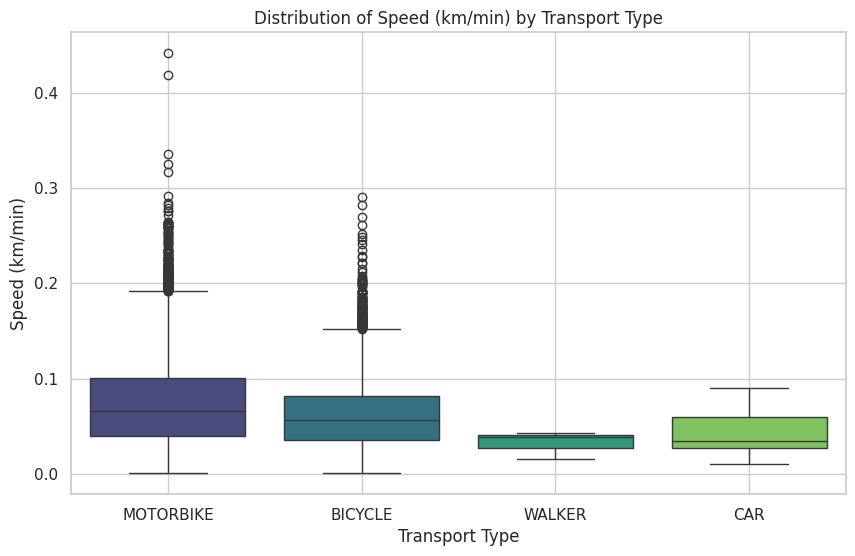

,speed_km_per_min
0,0.031002
1,0.034142
2,0.042781
3,0.079974
4,0.034175
...,...
19907,0.059483
19908,0.127394
19909,0.068749
19910,0.031377


In [28]:
df_clean['speed_km_per_min'] = df_clean['distance_km'] / df_clean['delivery_time_minutes']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='tranport_type', y='speed_km_per_min', palette='viridis')
plt.title('Distribution of Speed (km/min) by Transport Type')
plt.xlabel('Transport Type')
plt.ylabel('Speed (km/min)')
plt.grid(True)
plt.show()

df_clean['speed_km_per_min']

## Store ID

Las variables de store id (store name y store coorditanes ID) estan incompletas. Para identificar las tiendas individualmente, podemos crear una variable tipo object que sea el resultado de concatenar pickup_latitude y pickup_longitud (las coordenadas son lo suficientemente precisas -6 puntos decimales- para identificar un cuadrado de 11m, mas que suficiente para una tienda)

In [29]:
df_clean['store'] = df_clean['pickup_latitude'].astype(str) + '_' + df_clean['pickup_longitude'].astype(str)

In [30]:
df_clean["store"].unique()

array(['48.8610457_2.2754414999999426', '48.8715778_2.3044947',
       '48.8554611_2.3607756', ..., '48.8776527_2.3930951',
       '48.89070299999999_2.2878884', '48.8836295_2.2984802'],
      dtype=object)

In [31]:
df_clean['store'].head()

,store
0,48.8610457_2.2754414999999426
1,48.8715778_2.3044947
2,48.8554611_2.3607756
3,48.8596646_2.2856938
4,48.8634168_2.36124


In [32]:
# 1. Check the actual cardinality and frequency distribution
store_counts = df_clean['store'].value_counts()
print(f"Unique stores: {len(store_counts)}")
print(f"Stores with <5 orders: {(store_counts < 5).sum()}")
print(store_counts.describe())

Unique stores: 3086
Stores with <5 orders: 2453
count    3086.000000
mean        6.211925
std        24.007167
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       563.000000
Name: count, dtype: float64


In [33]:
min_orders = 10
frequent_stores = store_counts[store_counts >= min_orders].index
df_clean['store'] = df_clean['store'].where(df_clean['store'].isin(frequent_stores), 'other_store')
print(df_clean['store'].nunique())

366


## Areas

Actualmente las coordenadas de pickup y dropoff son demasiado precisas para que el modelo aprenda patrones por área. Asi que, hemos decidido cortar las variables de latitudes y longitudes a 2 decimales (da una área de 1kmx1km, en lugar de la actual de tan solo 10cm).

In [34]:
import numpy as np

df_clean['pickup_latitude'] = np.floor(df_clean['pickup_latitude'] * 100) / 100
df_clean['pickup_longitude'] = np.floor(df_clean['pickup_longitude'] * 100) / 100
df_clean['delivery_latitude'] = np.floor(df_clean['delivery_latitude'] * 100) / 100
df_clean['delivery_longitude'] = np.floor(df_clean['delivery_longitude'] * 100) / 100

## Meteorología

In [35]:
import pandas as pd

# Load weather data
weather_df = pd.read_csv(
    'World_Capitals_Daily_Weather_2015_2025.csv',
    sep=',',
    engine='python'
)

# Prepare dates
weather_df['date_only'] = pd.to_datetime(weather_df['date']).dt.normalize()
df_clean['date_only'] = pd.to_datetime(df_clean['activation_time_local']).dt.normalize()

# Filter Paris weather
paris_weather = weather_df[weather_df['city'] == 'Paris'].copy()

# Select relevant weather variables
weather_features = [
    'date_only',
    'temp_mean_c',
    'precipitation_mm',
    'wind_max_kmh',
    'humidity_pct'
]

weather_daily = paris_weather[weather_features].copy()

# Ensure one row per date
weather_daily = (
    weather_daily
    .groupby('date_only', as_index=False)
    .mean()
)

# Drop previous weather columns if they already exist
weather_cols = [
    'temp_mean_c',
    'precipitation_mm',
    'wind_max_kmh',
    'humidity_pct',
    'pu_temp_mean_c',
    'pu_precipitation_mm',
    'pu_wind_max_kmh',
    'pu_humidity_pct',
    'dl_temp_mean_c',
    'dl_precipitation_mm',
    'dl_wind_max_kmh',
    'dl_humidity_pct'
]

df_clean = df_clean.drop(columns=weather_cols, errors='ignore')

# Merge weather by date
df_clean = df_clean.merge(
    weather_daily,
    on='date_only',
    how='left',
    validate='many_to_one'
)

display(df_clean.head())

,courier_id,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,pickup_latitude,...,day_of_week,date,distance_km,speed_km_per_min,store,date_only,temp_mean_c,precipitation_mm,wind_max_kmh,humidity_pct
0,441.0,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,48.86,...,1,2019-10-01,0.882526,0.031002,48.8610457_2.2754414999999426,2019-10-01,17.3,3.8,27.1,83.0
1,239.0,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,48.87,...,1,2019-10-01,0.995245,0.034142,48.8715778_2.3044947,2019-10-01,17.3,3.8,27.1,83.0
2,351.0,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,48.85,...,1,2019-10-01,1.284852,0.042781,48.8554611_2.3607756,2019-10-01,17.3,3.8,27.1,83.0
3,391.0,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,48.85,...,2,2019-10-02,3.325588,0.079974,other_store,2019-10-02,13.2,0.9,21.3,70.0
4,263.0,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,48.86,...,2,2019-10-02,0.885714,0.034175,48.8634168_2.36124,2019-10-02,13.2,0.9,21.3,70.0


In [36]:
df_clean['is_rainy_day'] = (df_clean['precipitation_mm'] > 0).astype(int)
df_clean['heavy_rain'] = (df_clean['precipitation_mm'] > 5).astype(int)
df_clean['high_wind'] = (df_clean['wind_max_kmh'] > 30).astype(int)

df_clean['rain_x_distance'] = df_clean['precipitation_mm'] * df_clean['distance_km']
df_clean['wind_x_distance'] = df_clean['wind_max_kmh'] * df_clean['distance_km']

In [37]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19170 entries, 0 to 19169
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   courier_id                   19170 non-null  float64       
 1   vertical                     19170 non-null  object        
 2   gtv                          19170 non-null  float64       
 3   delivery_fee                 19170 non-null  float64       
 4   activation_time_local        19170 non-null  datetime64[ns]
 5   courier_started_order_local  19170 non-null  datetime64[ns]
 6   pickup_time_local            19170 non-null  datetime64[ns]
 7   delivery_time_local          19170 non-null  datetime64[ns]
 8   tranport_type                19170 non-null  object        
 9   pickup_latitude              19170 non-null  float64       
 10  pickup_longitude             19170 non-null  float64       
 11  delivery_latitude            19170 non-nu

## Horas punta -categorica

Intentamos captar horas punta

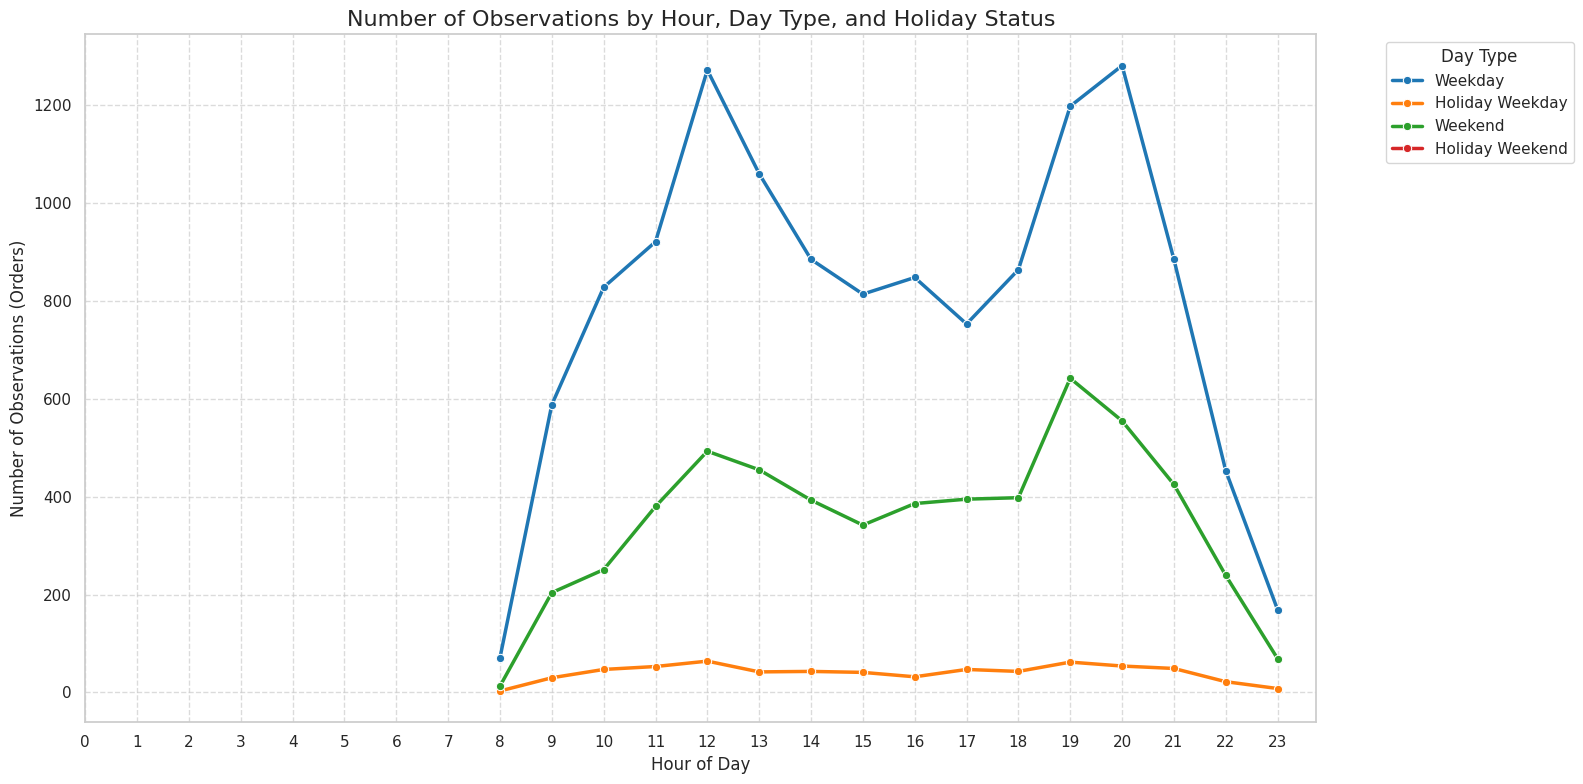

In [38]:
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create 'is_weekend' feature (0 for weekday, 1 for weekend)
# day_of_week: Monday=0, Sunday=6
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6])

# 2. Create 'is_holiday' feature
# Assuming data is for 2019, as per previous EDA plots
fr_holidays = holidays.France(years=2019)
df_clean['is_holiday'] = df_clean['activation_time_local'].dt.date.isin(fr_holidays)

# 3. Create a combined 'day_type' categorical variable
def get_day_type(row):
    if row['is_weekend'] and row['is_holiday']:
        return 'Holiday Weekend'
    elif row['is_weekend']:
        return 'Weekend'
    elif row['is_holiday']: # This means it's a weekday and a holiday
        return 'Holiday Weekday'
    else:
        return 'Weekday'

df_clean['day_type'] = df_clean.apply(get_day_type, axis=1)

# 4. Group data to get observation counts per hour for each day_type
hourly_day_type_counts = df_clean.groupby(['hour_of_day', 'day_type']).size().reset_index(name='order_count')

# Define a specific order for 'day_type' for consistent plotting
day_type_order = ['Weekday', 'Holiday Weekday', 'Weekend', 'Holiday Weekend']
hourly_day_type_counts['day_type'] = pd.Categorical(hourly_day_type_counts['day_type'], categories=day_type_order, ordered=True)

# Sort for better line plot drawing
hourly_day_type_counts = hourly_day_type_counts.sort_values(by=['day_type', 'hour_of_day'])

# 5. Create the line plot
plt.figure(figsize=(16, 8))
sns.lineplot(data=hourly_day_type_counts, x='hour_of_day', y='order_count', hue='day_type', marker='o', palette='tab10', linewidth=2.5)

plt.title('Number of Observations by Hour, Day Type, and Holiday Status', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Observations (Orders)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Day Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Vemos que:
- Weekdat & weekend : A LAS 12 Y 19 horas hay peaks
- Holiday weekdayy: No hay un peak claro

Creamos una variable que marce "peak hours" todas las observaciones que sean de sean entre 11h y 13h, y 18h y 20h cuando sea weekdayu o weekend

In [39]:
# Define peak hour conditions
peak_hours_morning = (df_clean['hour_of_day'] >= 11) & (df_clean['hour_of_day'] <= 13)
peak_hours_evening = (df_clean['hour_of_day'] >= 18) & (df_clean['hour_of_day'] <= 20)

# Combine conditions for peak hours on non-holidays
df_clean['peak_hours'] = ((peak_hours_morning | peak_hours_evening) & (~df_clean['is_holiday'])).astype(int)

print("New feature 'peak_hours' created.")
print(df_clean[['hour_of_day', 'is_weekend', 'is_holiday', 'day_type', 'peak_hours']].head(10))

New feature 'peak_hours' created.
   hour_of_day  is_weekend  is_holiday day_type  peak_hours
0            9       False       False  Weekday           0
1            9       False       False  Weekday           0
2           15       False       False  Weekday           0
3           10       False       False  Weekday           0
4           12       False       False  Weekday           1
5           13       False       False  Weekday           1
6           18       False       False  Weekday           1
7           18       False       False  Weekday           1
8           19       False       False  Weekday           1
9           10       False       False  Weekday           0


## Experiencia del courier

In [40]:
# df_clean debe estar ordenado cronológicamente
df_clean = df_clean.sort_values('activation_time_local')

# Nº de pedidos completados por ese courier ANTES del pedido actual
# cumcount() cuenta 0,1,2,... en orden de aparición -> solo usa el pasado
df_clean['courier_experience'] = df_clean.groupby('courier_id').cumcount()

# Importante: dropear courier_id para no usar la identidad directamente
df_clean = df_clean.drop('courier_id', axis=1)

## Velocidad promedio de cada transporte

In [41]:
# Velocidad media (simple) por tipo de transporte
speed_dict = df_clean.groupby('tranport_type', observed=True)['speed_km_per_min'].mean().to_dict()

# Mapear de vuelta al dataframe
df_clean['avg_speed_by_transport'] = df_clean['tranport_type'].map(speed_dict)

print("Velocidad media por tipo de transporte:")
print(speed_dict)
print(df_clean[['tranport_type', 'avg_speed_by_transport']].head())

Velocidad media por tipo de transporte:
{'BICYCLE': 0.06210115783179762, 'CAR': 0.0420645464168142, 'MOTORBIKE': 0.07416767244756582, 'WALKER': 0.032141323731547156}
      tranport_type  avg_speed_by_transport
17182     MOTORBIKE                0.074168
1086      MOTORBIKE                0.074168
6536      MOTORBIKE                0.074168
1           BICYCLE                0.062101
0         MOTORBIKE                0.074168


# Modelos

In [42]:
df_clean.columns

Index(['vertical', 'gtv', 'delivery_fee', 'activation_time_local',
       'courier_started_order_local', 'pickup_time_local',
       'delivery_time_local', 'tranport_type', 'pickup_latitude',
       'pickup_longitude', 'delivery_latitude', 'delivery_longitude',
       'saturation', 'delivery_time_minutes', 'hour_of_day', 'day_of_week',
       'date', 'distance_km', 'speed_km_per_min', 'store', 'date_only',
       'temp_mean_c', 'precipitation_mm', 'wind_max_kmh', 'humidity_pct',
       'is_rainy_day', 'heavy_rain', 'high_wind', 'rain_x_distance',
       'wind_x_distance', 'is_weekend', 'is_holiday', 'day_type', 'peak_hours',
       'courier_experience', 'avg_speed_by_transport'],
      dtype='object')

## Consolidación del Feature Set




In [43]:
df_final=df_clean.drop([
    "activation_time_local",
    "courier_started_order_local", # Intra-timestamp-Dataleakage
    "pickup_time_local",# Intra-timestamp-Dataleakage
    "delivery_time_local",# Intra-timestamp-Dataleakage
    "date", # Raw datetime columns already transformed into hour/day/weather
    "date_only",
    "speed_km_per_min"
    ],axis=1)

# Ensure the new feature is in df_final if it wasn't dropped already
# If df_clean was used to create df_final directly after adding the feature, this is already implicitly handled.
# However, it's good practice to ensure. Here, df_final is recreated, so the feature should be there.
# No explicit merge needed here if df_final is being recreated from df_clean which already contains the feature.

In [44]:
df_final.columns

Index(['vertical', 'gtv', 'delivery_fee', 'tranport_type', 'pickup_latitude',
       'pickup_longitude', 'delivery_latitude', 'delivery_longitude',
       'saturation', 'delivery_time_minutes', 'hour_of_day', 'day_of_week',
       'distance_km', 'store', 'temp_mean_c', 'precipitation_mm',
       'wind_max_kmh', 'humidity_pct', 'is_rainy_day', 'heavy_rain',
       'high_wind', 'rain_x_distance', 'wind_x_distance', 'is_weekend',
       'is_holiday', 'day_type', 'peak_hours', 'courier_experience',
       'avg_speed_by_transport'],
      dtype='object')

In [45]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19170 entries, 17182 to 13503
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vertical                19170 non-null  object 
 1   gtv                     19170 non-null  float64
 2   delivery_fee            19170 non-null  float64
 3   tranport_type           19170 non-null  object 
 4   pickup_latitude         19170 non-null  float64
 5   pickup_longitude        19170 non-null  float64
 6   delivery_latitude       19170 non-null  float64
 7   delivery_longitude      19170 non-null  float64
 8   saturation              19170 non-null  float64
 9   delivery_time_minutes   19170 non-null  float64
 10  hour_of_day             19170 non-null  int32  
 11  day_of_week             19170 non-null  int32  
 12  distance_km             19170 non-null  float64
 13  store                   19170 non-null  object 
 14  temp_mean_c             19170 non-null 

In [46]:
print(df_final["vertical"].nunique())
print(df_final["tranport_type"].nunique())
print(df_final["store"].nunique())
print(df_final["day_type"].nunique())
print(df_final["day_type"].unique())


3
4
366
3
['Weekday' 'Weekend' 'Holiday Weekday']


## Modelo

In [47]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define target and features
y = df_final['delivery_time_minutes']
X = df_final.drop('delivery_time_minutes', axis=1)

# Identify categorical features (from previous steps)
categorical_features = [
    'vertical',
    'tranport_type',
    'store',
    'day_type',
    'is_weekend',
    'is_holiday'
]

# Convert categorical features to 'category' dtype for LightGBM
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize LightGBM Regressor model
lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1,max_bins=3000)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31],
    'max_depth': [-1, 10]
}

# Set up GridSearchCV
# Scoring is 'neg_mean_absolute_error' because GridSearchCV minimizes by default.
# To maximize MAE, we minimize its negative.
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV for LightGBM (maximizing MAE)...")
grid_search.fit(X_train, y_train, categorical_feature=categorical_features)
print("GridSearchCV complete.")

# Get the best model
best_lgbm_model = grid_search.best_estimator_

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best MAE on validation sets: {-grid_search.best_score_:.4f}")

# Make predictions on the test set with the best model
y_pred = best_lgbm_model.predict(X_test)

# Evaluate the best model on the test set
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nBest Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Starting GridSearchCV for LightGBM (maximizing MAE)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004864 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11641
[LightGBM] [Info] Number of data points in the train set: 15336, number of used features: 28
[LightGBM] [Info] Start training from score 36.329974
GridSearchCV complete.

Best parameters found: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}
Best MAE on validation sets: 6.7128

Best Model Evaluation on Test Set:
Mean Absolute Error (MAE): 6.7777
Mean Squared Error (MSE): 71.9802
Root Mean Squared Error (RMSE): 8.4841
R-squared (R2): 0.5413


In [49]:
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer
import numpy as np
import pandas as pd

# Ensure categorical features are of 'category' dtype in the full dataset X
categorical_features = [
    'vertical',
    'tranport_type',
    'store',
    'day_type',
    'is_weekend',
    'is_holiday'
]

for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# Define the MAE scorer. We use `greater_is_better=False` because lower MAE is better.
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Set up K-Fold Cross-Validation
n_splits = 5 # A common number of folds
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"Performing {n_splits}-Fold Cross-Validation on the optimized LightGBM model...")

# Perform cross-validation using the best_lgbm_model
cv_results = cross_val_score(
    best_lgbm_model,
    X,
    y,
    cv=kf,
    scoring=mae_scorer,
    n_jobs=-1 # Use all available cores for parallel processing
)

# The scores are negative MAE because `mae_scorer` was defined with `greater_is_better=False`.
# Convert them to positive MAE for easier interpretation.
cv_mae_scores = -cv_results

print("\nCross-Validation Complete.")
print(f"MAE scores for each fold: {cv_mae_scores}")
print(f"Mean MAE across {n_splits} folds: {np.mean(cv_mae_scores):.4f}")
print(f"Standard Deviation of MAE across {n_splits} folds: {np.std(cv_mae_scores):.4f}")

# If you actually intended to use K-Means for clustering, please specify what data you'd like to cluster
# (e.g., the features 'X', the model's residuals, or something else) and for what purpose.

Performing 5-Fold Cross-Validation on the optimized LightGBM model...

Cross-Validation Complete.
MAE scores for each fold: [6.77766782 6.73180304 6.69770046 6.60375526 6.65546019]
Mean MAE across 5 folds: 6.6933
Standard Deviation of MAE across 5 folds: 0.0601


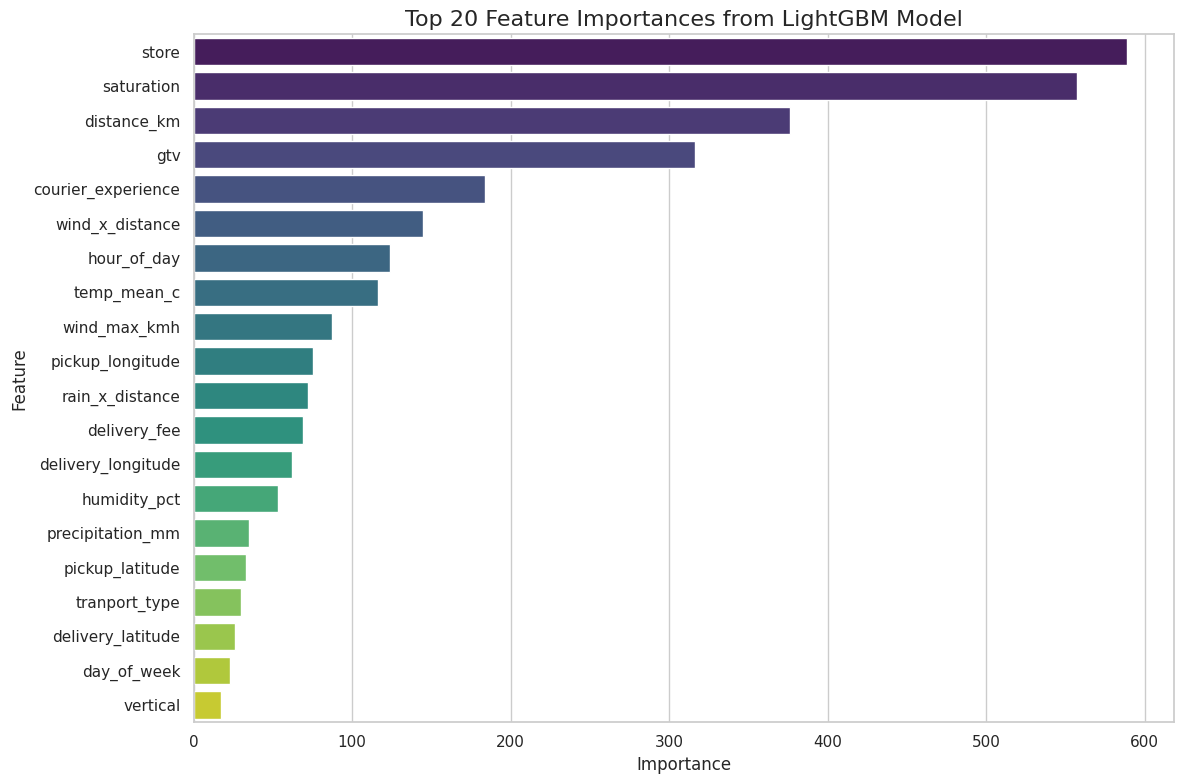

Top 20 Feature Importances:
               Feature  Importance
12               store         589
8           saturation         557
11         distance_km         376
1                  gtv         316
26  courier_experience         184
21     wind_x_distance         145
9          hour_of_day         124
13         temp_mean_c         116
15        wind_max_kmh          87
5     pickup_longitude          75
20     rain_x_distance          72
2         delivery_fee          69
7   delivery_longitude          62
16        humidity_pct          53
14    precipitation_mm          35
4      pickup_latitude          33
3        tranport_type          30
6    delivery_latitude          26
10         day_of_week          23
0             vertical          17


In [48]:
import matplotlib.pyplot as plt

# Get feature importances from the best model
feature_importances = best_lgbm_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances from LightGBM Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 20 Feature Importances:")
print(importance_df.head(20))